Living in rural Devon, we are surrounded by many roads that have a nominal speed limit of 60mph on which that would be a wholly inadvisable speed to travel, with likely speeds generally falling closer to the 20-40mph range. 

For some journeys, this could have a significant impact when calculating the journey time using r5py, which assumes free-flowing traffic at the maximum permitted speed for the road. 

:::{.callout-tip}
If you're a bilingual R/Python user, you could choose to switch over to r5r at this point as they [natively support modifying max car speeds, both at a granular level or applying a more general scaling factor to certain types of roads](https://ipeagit.github.io/r5r/articles/scenarios.html). 
:::

In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\lokigi\.venv\Scripts\python.exe
3.13.12 (main, Mar 24 2026, 22:56:40) [MSC v.1944 64 bit (AMD64)]


In [3]:
# Usage
# import os
# import tempfile

# WORK_TEMP = r"C:\lokigi\examples\datasets"

# os.environ["TMP"] = WORK_TEMP
# os.environ["TEMP"] = WORK_TEMP
# tempfile.tempdir = WORK_TEMP


In [4]:
from pathlib import Path
import osmium
import re
import r5py
import pandas as pd
import geopandas
import contextily as cx


In [5]:

class AdvancedSpeedUpdater(osmium.SimpleHandler):
    def __init__(self, writer, minor_road_cap=None, traffic_multiplier=None,
                 debug=False, debug_limit=50):
        super().__init__()
        self.writer = writer
        self.minor_road_cap = minor_road_cap
        self.traffic_multiplier = traffic_multiplier
        self.debug = debug
        self.debug_limit = debug_limit
        self.debug_count = 0
        self.changes_made = 0

        # OSM highway tags generally considered "minor"
        self.minor_road_types = {
            'tertiary', 'unclassified', 'residential',
            'living_street', 'service', 'track'
        }

    def _parse_speed(self, speed_str: str) -> float:
        """Extracts a numeric speed value from common UK OSM maxspeed formats."""
        if not speed_str:
            return None

        speed_str = speed_str.lower()
        # Handle the UK national speed limit for single carriageways
        if speed_str == 'national':
            return 60.0

        # Extract the first block of digits found
        match = re.search(r'(\d+)', speed_str)
        if match:
            return float(match.group(1))

        return None

    def _debug_print(self, message):
        """Avoid flooding console with millions of lines."""
        if self.debug and self.debug_count < self.debug_limit:
            print(message)
            self.debug_count += 1

    def node(self, n):
        self.writer.add_node(n)

    def relation(self, r):
        self.writer.add_relation(r)

    def way(self, w):
        tags = dict(w.tags)

        # --- DEBUG: inspect all tags on this way ---
        self._debug_print(f"[WAY {w.id}] ALL TAGS:")
        for k, v in tags.items():
            self._debug_print(f"    {k}: {v}")

        # specifically highlight anything related to maxspeed
        maxspeed_related = {k: v for k, v in tags.items() if "maxspeed" in k.lower()}
        if maxspeed_related:
            self._debug_print(f"[WAY {w.id}] MAXSPEED-RELATED TAGS:")
            for k, v in maxspeed_related.items():
                self._debug_print(f"    {k}: {v}")

        highway = tags.get('highway')

        # We only care about drivable roads
        if not highway:
            self.writer.add_way(w)
            return

        current_speed_str = tags.get('maxspeed')
        speed_val = self._parse_speed(current_speed_str)

        inferred_missing_speed = False

        # If minor road has no speed, assume router default = 60 mph
        if speed_val is None and highway in self.minor_road_types:
            speed_val = 60.0
            inferred_missing_speed = True

        # If we still don't have a speed (e.g., untagged major road), pass it through
        if speed_val is None:
            self.writer.add_way(w)
            return

        original_speed_val = speed_val
        change_reasons = []

        # --- 1. Apply Minor Road Cap ---
        if self.minor_road_cap is not None and highway in self.minor_road_types:
            if speed_val > self.minor_road_cap:
                speed_val = float(self.minor_road_cap)
                change_reasons.append(
                    f"minor road cap -> {self.minor_road_cap}"
                )

        # --- 2. Apply Traffic Modifier ---
        if self.traffic_multiplier is not None:
            old_speed = speed_val
            speed_val = speed_val * self.traffic_multiplier

            if speed_val != old_speed:
                change_reasons.append(
                    f"traffic multiplier x{self.traffic_multiplier}"
                )

        # If the speed changed, update the tags and write the modified way
        if speed_val != original_speed_val:
            new_speed_str = f"{int(round(speed_val))} mph"
            # tags['maxspeed'] = str(int(round(speed_val)))
            tags['maxspeed'] = new_speed_str
            tags['maxspeed:motorcar'] = new_speed_str
            tags.pop("maxspeed:type", None)

            self._debug_print(
                f"[WAY {w.id}] "
                f"{highway} | "
                f"original='{current_speed_str}' "
                f"(parsed={original_speed_val}) -> "
                f"new='{speed_val} ({new_speed_str})' | "
                f"reasons={change_reasons} | "
                f"inferred_missing={inferred_missing_speed}"
            )

            self.changes_made += 1

            self.writer.add_way(w.replace(tags=tags))
        else:
            # Write unmodified
            self.writer.add_way(w)

def process_uk_network(
        input_file: str,
        output_file: str,
        minor_road_cap=30,
        traffic_multiplier=None,
        debug=False,
        debug_limit=50
    ):

    abs_input = str(Path(input_file).resolve())
    print(f"Reading from {abs_input}")
    abs_output = str(Path(output_file).resolve())
    print(f"Will write to {abs_output}")

    output_path = Path(abs_output)

    if output_path.exists():
        output_path.unlink()

    writer = osmium.SimpleWriter(abs_output)

    try:
        handler = AdvancedSpeedUpdater(
            writer=writer,
            minor_road_cap=minor_road_cap,
            traffic_multiplier=traffic_multiplier,
            debug=debug,
            debug_limit=debug_limit
        )

        print(f"Processing {abs_input}...")
        handler.apply_file(abs_input)

        if debug:
            print(
                f"Debug output truncated at "
                f"{handler.debug_count}/{debug_limit} changes"
            )
        print(f"Done! Saved to {abs_output}")
        print(f"Total Changes made: {handler.changes_made}")

    finally:
        writer.close()

In [6]:
process_uk_network(
    "../../datasets/devon-260422.osm.pbf",
    "../../datasets/devon-260422-modified.osm.pbf",
    debug=True,
    minor_road_cap=5,
    debug_limit=50
    )


Reading from C:\lokigi\examples\datasets\devon-260422.osm.pbf
Will write to C:\lokigi\examples\datasets\devon-260422-modified.osm.pbf
Processing C:\lokigi\examples\datasets\devon-260422.osm.pbf...
[WAY 2252] ALL TAGS:
    highway: residential
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Holland Road
[WAY 2252] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2252] residential | original='30 mph' (parsed=30.0) -> new='5.0 (5 mph)' | reasons=['minor road cap -> 5'] | inferred_missing=False
[WAY 2253] ALL TAGS:
    highway: tertiary
    lanes: 2
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Bradham Lane
    surface: asphalt
[WAY 2253] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2253] tertiary | original='30 mph' (parsed=30.0) -> new='5.0 (5 mph)' | reasons=['minor road cap -> 5'] | inferred_missing=False
[WAY 2255] ALL TAGS:
    foot: yes
  

And let's repeat this applying a simple multiplier for traffic. 

In [7]:
process_uk_network(
    "../../datasets/devon-260422.osm.pbf",
    "../../datasets/devon-260422-modified-traffic.osm.pbf",
    debug=True,
    traffic_multiplier=0.6, # Lower = slower max speed assumed
    debug_limit=50
    )


Reading from C:\lokigi\examples\datasets\devon-260422.osm.pbf
Will write to C:\lokigi\examples\datasets\devon-260422-modified-traffic.osm.pbf
Processing C:\lokigi\examples\datasets\devon-260422.osm.pbf...
[WAY 2252] ALL TAGS:
    highway: residential
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Holland Road
[WAY 2252] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2252] residential | original='30 mph' (parsed=30.0) -> new='18.0 (18 mph)' | reasons=['traffic multiplier x0.6'] | inferred_missing=False
[WAY 2253] ALL TAGS:
    highway: tertiary
    lanes: 2
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Bradham Lane
    surface: asphalt
[WAY 2253] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2253] tertiary | original='30 mph' (parsed=30.0) -> new='18.0 (18 mph)' | reasons=['traffic multiplier x0.6'] | inferred_missing=False
[WAY 2255] ALL TA

#### Confirming the change has worked

Let's load this modified file back in to confirm the change has taken. 

In [8]:
class WayInspector(osmium.SimpleHandler):
    def __init__(self, way_ids):
        super().__init__()
        self.way_ids = set(way_ids)

    def way(self, w):
        if w.id not in self.way_ids:
            return

        tags = dict(w.tags)

        highway = tags.get("highway")
        maxspeed = tags.get("maxspeed")

        print("\n" + "=" * 80)
        print(f"WAY {w.id}")
        print(f"highway: {highway}")
        print(f"maxspeed: {maxspeed}")

        # --- highlight maxspeed-related tags specifically ---
        maxspeed_tags = {k: v for k, v in tags.items() if "maxspeed" in k.lower()}
        if maxspeed_tags:
            print("\n-- maxspeed-related tags --")
            for k, v in maxspeed_tags.items():
                print(f"  {k}: {v}")

        # --- show source-related overrides (very common culprit) ---
        source_tags = {k: v for k, v in tags.items() if "source" in k.lower()}
        if source_tags:
            print("\n-- source-related tags --")
            for k, v in source_tags.items():
                print(f"  {k}: {v}")

        # --- optional: full dump (kept last so it doesn't obscure key info) ---
        print("\n-- all tags --")
        for k, v in sorted(tags.items()):
            print(f"  {k}: {v}")

inspector = WayInspector([
    2253  # from the debug output
])


##### Original File

In [9]:
inspector.apply_file("../../datasets/devon-260422.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 30 mph

-- maxspeed-related tags --
  maxspeed: 30 mph
  maxspeed:type: GB:nsl_restricted

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 30 mph
  maxspeed:type: GB:nsl_restricted
  name: Bradham Lane
  surface: asphalt


##### Modified file

In [10]:
inspector.apply_file("../../datasets/devon-260422-modified.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 5 mph

-- maxspeed-related tags --
  maxspeed: 5 mph
  maxspeed:motorcar: 5 mph

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 5 mph
  maxspeed:motorcar: 5 mph
  name: Bradham Lane
  surface: asphalt


And our traffic file:

In [11]:
inspector.apply_file("../../datasets/devon-260422-modified-traffic.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 18 mph

-- maxspeed-related tags --
  maxspeed: 18 mph
  maxspeed:motorcar: 18 mph

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 18 mph
  maxspeed:motorcar: 18 mph
  name: Bradham Lane
  surface: asphalt


Let's now show the impact of this change. First, let's do the calculation on the unedited file. 

Let's just calculate a single route we know covers a lot of minor roads. 

Travelling from Cullompton to Cheriton Fitzpaine takes us along a large number of minor roads, so is a good test case. 

Let's travel from EX15 1HN to EX17 4JG. 

In [12]:
origins = pd.DataFrame([{'id':'EX15 1HN', 'longitude': -3.3964515912457207, 'latitude': 50.85510704952628},
                        ])

origins = geopandas.GeoDataFrame(
    origins,
    geometry = geopandas.points_from_xy(
        origins['longitude'],
        origins['latitude']
        ),
    crs = 'EPSG:4326'
    )

origins

,id,longitude,latitude,geometry
0,EX15 1HN,-3.396452,50.855107,POINT (-3.39645 50.85511)


In [13]:
destinations = pd.DataFrame([{'id':'EX17 4JG', 'longitude': -3.6102812023506217, 'latitude': 50.844712763862496},
                             {'id':'Exeter Airport', 'longitude': -3.413323770890914, 'latitude':50.73714162801647},
                             {'id': "Cornish Arms Tavistock", 'longitude': -4.146750479096123, 'latitude': 50.551448737522115}])

destinations = geopandas.GeoDataFrame(
    destinations,
    geometry = geopandas.points_from_xy(
        destinations['longitude'],
        destinations['latitude']
        ),
    crs = 'EPSG:4326'
    )

destinations

,id,longitude,latitude,geometry
0,EX17 4JG,-3.610281,50.844713,POINT (-3.61028 50.84471)
1,Exeter Airport,-3.413324,50.737142,POINT (-3.41332 50.73714)
2,Cornish Arms Tavistock,-4.146750,50.551449,POINT (-4.14675 50.55145)


In [14]:
transport_network = r5py.TransportNetwork(
    "../../datasets/devon-260422.osm.pbf",
)

travel_time_matrix_car = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

In [15]:
travel_time_matrix_car

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


Let's take a look at a detailed breakdown of this journey. 

:::{.callout-warning}
This point-to-point router isn't really r5py's strong point! So these routes may look a bit squiffy - but they do show us something useful for our experiments, so I've left it in. 

This is explained in the following github issues: https://github.com/conveyal/r5/issues/863, https://github.com/r5py/r5py/issues/386

>  We haven't used the point-to-point routing server for many years and it is not actively maintained. This dates from a time when we were exploring use of R5 as a replacement for OpenTripPlanner, but there has since been a clearer division of roles between the two projects with OpenTripPlanner 2 handling passenger-facing and point-to-point routing, while R5 is specialized in many-to-many urban analytics use cases. The point-to-point routing code paths do work somewhat differently than the one-to-many routing we use heavily for travel time mapping and accessibility calculations. We have not (yet) removed the point-to-point functionality in case anyone finds it useful, but realistically we probably won't spend time exploring issues with this part of the codebase.


:::

In [16]:
detailed_itineraries = r5py.DetailedItineraries(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,
)

detailed_itineraries

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,20403.065,0 days 00:35:49,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:26:13,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,86600.881,0 days 01:59:35,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


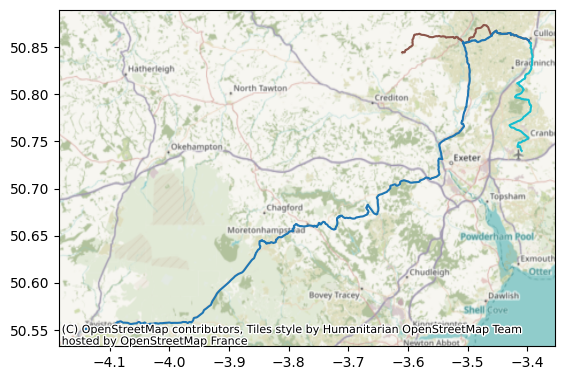

In [17]:
ax = detailed_itineraries.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

#### Repeating this with the modified matrix

Now let's repeat this with our new matrix.

In [18]:
transport_network_modified = r5py.TransportNetwork(
    "../../datasets/devon-260422-modified.osm.pbf",
)

Our travel times appear to be unchanged. 

In [19]:
travel_time_matrix_car_modified = r5py.TravelTimeMatrix(
    transport_network_modified,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

travel_time_matrix_car_modified

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


In [20]:
detailed_itineraries_modified = r5py.DetailedItineraries(
    transport_network_modified,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,

)

In [21]:
detailed_itineraries_modified

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,21388.334,0 days 00:35:47,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:32:57,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,86600.881,0 days 01:58:39,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


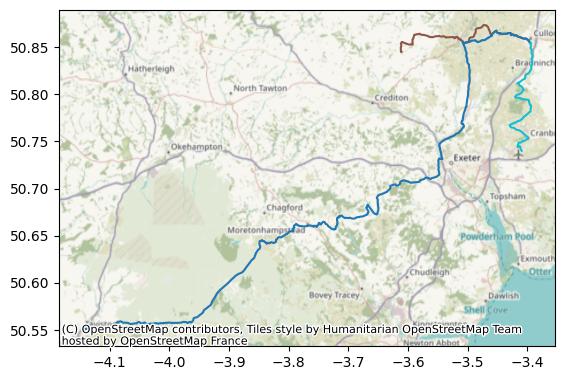

In [22]:
ax = detailed_itineraries_modified.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries_modified.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

#### Repeating with our traffic-altered file

Finally, let's repeat with our traffic-altered file. 

In [23]:
transport_network_modified_traffic = r5py.TransportNetwork(
    "../../datasets/devon-260422-modified-traffic.osm.pbf",
)

In [24]:
travel_time_matrix_car_modified_traffic = r5py.TravelTimeMatrix(
    transport_network_modified_traffic,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

travel_time_matrix_car_modified

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


In [25]:
detailed_itineraries_modified_traffic = r5py.DetailedItineraries(
    transport_network_modified_traffic,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,

)

In [26]:
detailed_itineraries_modified_traffic

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,21388.334,0 days 00:26:54,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:25:06,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,85051.652,0 days 01:29:07,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


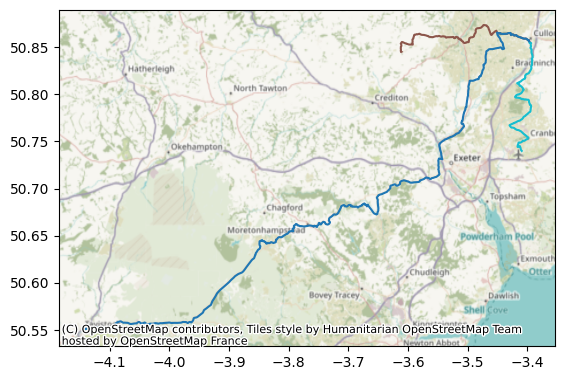

In [27]:
ax = detailed_itineraries_modified_traffic.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries_modified_traffic.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

## Valhalla

Let's compare with valhalla, a routing engine that's much more focussed on car travel times. 

In the past, valhalla had to be set up in a fairly daunting way, but we now have the pyvalhalla option, which is much more approachable!

In [43]:
from pathlib import Path
import subprocess


def prepare_valhalla_network(
    osm_path,
    output_dir=None,
    output_name=None,
    force_rebuild=False,
):
    """
    Build Valhalla routing tiles from an .osm.pbf file.

    Parameters
    ----------
    osm_path : str or Path
        Path to .osm.pbf file.

    output_dir : str or Path, optional
        Directory to store Valhalla outputs.
        Defaults to a folder beside the OSM named after the file stem.

    output_name : str, optional
        Base name for generated outputs.
        Used for:
            - config file
            - tile directory
            - traffic extract

        Defaults to OSM filename stem.

    force_rebuild : bool
        If True, rebuild even if outputs already exist.

    Returns
    -------
    dict
        {
            "config_path": ...,
            "tile_dir": ...,
            "traffic_path": ...
        }
    """

    osm_path = Path(osm_path).resolve()

    if not osm_path.exists():
        raise FileNotFoundError(f"OSM file not found: {osm_path}")

    # ------------------------------------------------------------
    # Derive sensible defaults
    # ------------------------------------------------------------

    if output_name is None:
        output_name = osm_path.stem.replace("-latest", "")

    if output_dir is None:
        output_dir = osm_path.parent / f"{output_name}_valhalla"

    output_dir = Path(output_dir).resolve()

    # ------------------------------------------------------------
    # Create output paths
    # ------------------------------------------------------------

    config_path = output_dir / f"{output_name}.json"
    tile_dir = output_dir / f"{output_name}_tiles"
    traffic_path = output_dir / f"{output_name}_traffic.tar"

    output_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Skip rebuild if tiles already exist
    # ------------------------------------------------------------

    if (
        tile_dir.exists()
        and any(tile_dir.iterdir())
        and config_path.exists()
        and not force_rebuild
    ):
        print("Using existing Valhalla build")

        return {
            "config_path": str(config_path),
            "tile_dir": str(tile_dir),
            "traffic_path": str(traffic_path),
        }

    # ------------------------------------------------------------
    # Generate config
    # ------------------------------------------------------------

    print("Generating Valhalla config...")

    with open(config_path, "w") as f:

        subprocess.run(
            [
                "valhalla_build_config",
                "--mjolnir-tile-dir",
                str(tile_dir),
                "--mjolnir-tile-extract",
                str(traffic_path),
            ],
            stdout=f,
            check=True,
        )

    # ------------------------------------------------------------
    # Build routing tiles
    # ------------------------------------------------------------

    print("Building Valhalla tiles (this may take a while)...")

    subprocess.run(
        [
            "valhalla_build_tiles",
            "-c",
            str(config_path),
            str(osm_path),
        ],
        check=True,
    )

    print("Valhalla build complete")

    return {
        "config_path": str(config_path),
        "tile_dir": str(tile_dir),
        "traffic_path": str(traffic_path),
    }

In [38]:
from valhalla import Actor
import pandas as pd

def build_time_matrix_valhalla(
    origins_gdf,
    destinations_gdf,
    valhalla_config_path,
    costing="auto"
):

    actor = Actor(valhalla_config_path)

    sources = [
        {
            "lat": geom.y,
            "lon": geom.x
        }
        for geom in origins_gdf.geometry
    ]

    targets = [
        {
            "lat": geom.y,
            "lon": geom.x
        }
        for geom in destinations_gdf.geometry
    ]

    request = {
        "sources": sources,
        "targets": targets,
        "costing": costing,
        "matrix_locations": len(sources) + len(targets),
        "verbose": False
    }

    matrix = actor.matrix(request)

    rows = []

    durations = matrix["sources_to_targets"]["durations"]
    distances = matrix["sources_to_targets"]["distances"]

    for i, origin in enumerate(origins_gdf.itertuples()):
        for j, destination in enumerate(destinations_gdf.itertuples()):

            # Access durations and distances from the correct structure
            travel_time_seconds = durations[i][j]
            distance_meters = distances[i][j]

            rows.append({
                "from_id": origin.id,
                "to_id": destination.id,
                "travel_time_minutes": travel_time_seconds / 60 if travel_time_seconds else None,
                "distance_km": distance_meters if distance_meters else None
            })

    return pd.DataFrame(rows)

In [32]:
config_path = prepare_valhalla_network(
    osm_path="../../datasets/devon-260422.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla.json"
)

Generating Valhalla config...
Building Valhalla tiles (this may take a while)...
Valhalla build complete


In [39]:
travel_time_matrix_car_valhalla = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla.json",
    costing="auto"
)

In [40]:
travel_time_matrix_car_valhalla

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,21.783333,26.503
1,EX15 1HN,Exeter Airport,14.166667,17.259
2,EX15 1HN,Cornish Arms Tavistock,54.383333,89.200


We can now repeat this with our modified files. 

In [45]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422-modified.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla-modified"
)

Generating Valhalla config...
Building Valhalla tiles (this may take a while)...
Valhalla build complete


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified_traffic.tar'}

In [46]:
travel_time_matrix_car_valhalla_modified = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla-modified.json",
    costing="auto"
)

In [47]:
travel_time_matrix_car_valhalla_modified

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,24.066667,20.382
1,EX15 1HN,Exeter Airport,16.100000,23.310
2,EX15 1HN,Cornish Arms Tavistock,54.350000,89.200


And finally, let's do this with our very heavy traffic file! 

In [ ]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422-modified-traffic.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla-modified-traffic"
)

In [ ]:
travel_time_matrix_car_valhalla_modified = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla-modified.json",
    costing="auto"
)